In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath("../utils"))  # repo utils/ (vendored sweep + shared helpers)


In [35]:
from sweep import sweep_load as sl
from sweep import raster
import numpy as np
import numpy.matlib
import matplotlib.pyplot as plt
from matplotlib import colors
from cycler import cycler
%matplotlib inline
from matplotlib.colors import Normalize
import matplotlib.image as mpimg

from matplotlib import cm
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.ticker import LogLocator, SymmetricalLogLocator
import matplotlib.patches as mpatches
from matplotlib.path import Path
from scipy.interpolate import splprep, splev
from matplotlib.patches import PathPatch

import sys
#sys.path.append("../utils")
#from utils import *

In [36]:
scale = 0.56
plt.rcParams.update({
    # Font and font sizes
    'font.family': 'sans-serif',
    'axes.labelsize': 8, 
    'axes.titlesize': 8,
    'font.size': 9,
    'legend.title_fontsize': 7,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,

    # Ticks
    'xtick.direction': 'in',
    'xtick.top': 'True',
    'ytick.direction': 'in',
    'ytick.right': 'True',

    'xtick.major.size': 5*scale,
    'xtick.major.width': 1.5*scale,
    'xtick.minor.size': 2.5*scale,
    'xtick.minor.width': 1.5*scale,

    'ytick.major.size': 5*scale,
    'ytick.major.width': 1.5*scale,
    'ytick.minor.size': 2.5*scale,
    'ytick.minor.width': 1.5*scale,


    # Linewidths
    'axes.linewidth': 1.5*scale,
    'lines.linewidth': 2.5*scale,
})


In [37]:
import matplotlib as mpl

# Contour plots from Julian

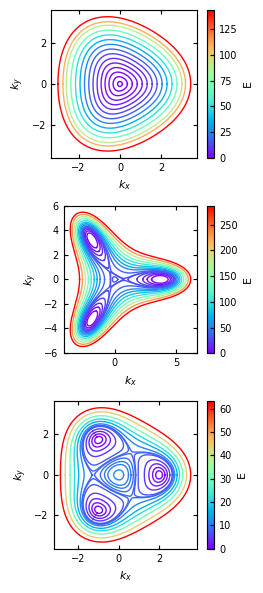

In [51]:
# kp_orbit_contours.py
#
# Traces constant-energy orbits of a one-band k·p dispersion by numerically
# integrating the arc-length ODE
#
#     dk/dt = ẑ × ∇ε / |∇ε|
#
# Exposes a single function plot_contours(fig, ax, hparams, cmap) that draws
# the orbit contours onto a caller-provided Matplotlib axis.

import math
import time
import numpy as np
import numba
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable

# ═══════════════════════════════════════════════════════════════════════════════
# Default parameters
# ═══════════════════════════════════════════════════════════════════════════════

# ── Anchor grid ───────────────────────────────────────────────────────────────
K_START  = 3.0     # innermost anchor radius (negative samples the other side)
K_END    = -3.0    # outermost anchor radius
N_ORBITS = 51     # number of radial distances; up to 3×N_ORBITS anchors total
K_MIN    = 0.1     # anchors with |r| < K_MIN are skipped (avoids gradient≈0 near Γ)

# ── Orbit tracing ─────────────────────────────────────────────────────────────
DS          = 0.005   # arc-length step size
CLOSURE_TOL = 0.01    # orbit closed when dist-to-start < this

# ── Deduplication ─────────────────────────────────────────────────────────────
DEDUP_TOL    = 0.15   # two orbits are duplicates if points are within this distance
FRAC_THRESH  = 0.75   # fraction of subsampled points that must overlap to deduplicate
DEDUP_STRIDE = 10     # stride for subsampling during deduplication


# ═══════════════════════════════════════════════════════════════════════════════
# k·p Hamiltonian
# ═══════════════════════════════════════════════════════════════════════════════
# ε(kx,ky) = H0 + Hx·kx + Hy·ky + Hxx·kx² + Hyy·ky² + Hxy·kx·ky + …

def _build_kp(hparams):
    """Pack (a2, a3, a4) into the flat coefficient array used by JIT kernels.
    Order: H0 Hx Hy Hxx Hyy Hxy Hxxx Hxxy Hxyy Hyyy Hxxxx Hxxxy Hxxyy Hxyyy Hyyyy
    """
    a2, a3, a4 = hparams
    kp = dict(
        H0    =  0.0,
        Hx    =  0.0,
        Hy    =  0.0,
        Hxx   =  a2,
        Hyy   =  a2,
        Hxy   =  0.0,
        Hxxx  = -a3,
        Hxxy  =  0.0,
        Hxyy  =  3*a3,
        Hyyy  =  0.0,
        Hxxxx =  a4,
        Hxxxy =  0.0,
        Hxxyy =  2*a4,
        Hxyyy =  0.0,
        Hyyyy =  a4,
    )
    kp_arr = np.array([
        kp['H0'],
        kp['Hx'],    kp['Hy'],
        kp['Hxx'],   kp['Hyy'],   kp['Hxy'],
        kp['Hxxx'],  kp['Hxxy'],  kp['Hxyy'],  kp['Hyyy'],
        kp['Hxxxx'], kp['Hxxxy'], kp['Hxxyy'], kp['Hxyyy'], kp['Hyyyy'],
    ], dtype=np.float64)
    return kp, kp_arr


# Python/numpy version — accepts scalar or array kx, ky (used for band-min grid).
def eval_disp(kp, kx, ky):
    e  = kp['H0']
    e += kp['Hx']    * kx
    e += kp['Hy']    * ky
    e += kp['Hxx']   * kx**2
    e += kp['Hyy']   * ky**2
    e += kp['Hxy']   * kx * ky
    e += kp['Hxxx']  * kx**3
    e += kp['Hxxy']  * kx**2 * ky
    e += kp['Hxyy']  * kx    * ky**2
    e += kp['Hyyy']  * ky**3
    e += kp['Hxxxx'] * kx**4
    e += kp['Hxxxy'] * kx**3 * ky
    e += kp['Hxxyy'] * kx**2 * ky**2
    e += kp['Hxyyy'] * kx    * ky**3
    e += kp['Hyyyy'] * ky**4
    return e


# ── JIT-compiled scalar kernels ───────────────────────────────────────────────

@numba.njit(cache=True)
def _grad_nb(c, kx, ky):
    gx  = c[1]
    gx += 2*c[3]*kx
    gx +=   c[5]*ky
    gx += 3*c[6]*kx*kx
    gx += 2*c[7]*kx*ky
    gx +=   c[8]*ky*ky
    gx += 4*c[10]*kx*kx*kx
    gx += 3*c[11]*kx*kx*ky
    gx += 2*c[12]*kx*ky*ky
    gx +=   c[13]*ky*ky*ky

    gy  = c[2]
    gy +=   c[5]*kx
    gy += 2*c[4]*ky
    gy +=   c[7]*kx*kx
    gy += 2*c[8]*kx*ky
    gy += 3*c[9]*ky*ky
    gy +=   c[11]*kx*kx*kx
    gy += 2*c[12]*kx*kx*ky
    gy += 3*c[13]*kx*ky*ky
    gy += 4*c[14]*ky*ky*ky

    return gx, gy


@numba.njit(cache=True)
def _trace_orbit_nb(c, kx0, ky0, ds, closure_tol, max_steps):
    """RK4 arc-length integrator; returns (xs, ys) as pre-allocated numpy arrays."""
    xs = np.empty(max_steps + 2)
    ys = np.empty(max_steps + 2)
    xs[0] = kx0; ys[0] = ky0
    n = 1

    kx, ky = kx0, ky0
    max_dist = 0.0

    for _ in range(max_steps):
        # Stage 1
        gx1, gy1 = _grad_nb(c, kx, ky)
        m1 = math.sqrt(gx1*gx1 + gy1*gy1)
        if m1 < 1e-14: break
        vx1 = -gy1/m1; vy1 = gx1/m1

        # Stage 2
        gx2, gy2 = _grad_nb(c, kx + 0.5*ds*vx1, ky + 0.5*ds*vy1)
        m2 = math.sqrt(gx2*gx2 + gy2*gy2)
        if m2 < 1e-14: break
        vx2 = -gy2/m2; vy2 = gx2/m2

        # Stage 3
        gx3, gy3 = _grad_nb(c, kx + 0.5*ds*vx2, ky + 0.5*ds*vy2)
        m3 = math.sqrt(gx3*gx3 + gy3*gy3)
        if m3 < 1e-14: break
        vx3 = -gy3/m3; vy3 = gx3/m3

        # Stage 4
        gx4, gy4 = _grad_nb(c, kx + ds*vx3, ky + ds*vy3)
        m4 = math.sqrt(gx4*gx4 + gy4*gy4)
        if m4 < 1e-14: break
        vx4 = -gy4/m4; vy4 = gx4/m4

        kx += ds/6.0*(vx1 + 2.0*vx2 + 2.0*vx3 + vx4)
        ky += ds/6.0*(vy1 + 2.0*vy2 + 2.0*vy3 + vy4)
        xs[n] = kx; ys[n] = ky
        n += 1

        dx = kx - kx0; dy = ky - ky0
        d = math.sqrt(dx*dx + dy*dy)
        if d > max_dist:
            max_dist = d
        if max_dist > 3.0*closure_tol and d < closure_tol:
            break

    xs[n] = kx0; ys[n] = ky0   # close the polygon
    n += 1
    return xs[:n], ys[:n]


@numba.njit(cache=True)
def _is_duplicate_nb(xs_b, ys_b, xs_a, ys_a, dist_tol, frac_thr, stride):
    n_b = len(xs_b); n_a = len(xs_a)
    n_close = 0; b_count = 0
    for i in range(0, n_b, stride):
        xb = xs_b[i]; yb = ys_b[i]
        b_count += 1
        for j in range(0, n_a, stride):
            dx = xb - xs_a[j]; dy = yb - ys_a[j]
            if math.sqrt(dx*dx + dy*dy) < dist_tol:
                n_close += 1
                break
    if b_count == 0:
        return False
    return (n_close / b_count) > frac_thr


# ═══════════════════════════════════════════════════════════════════════════════
# JIT warm-up  (triggers compilation on import)
# ═══════════════════════════════════════════════════════════════════════════════

_warmup_arr = np.zeros(15, dtype=np.float64)
_warmup_arr[3] = 1.0; _warmup_arr[4] = 1.0
_trace_orbit_nb(_warmup_arr, 1.0, 0.0, DS, CLOSURE_TOL, 10)
_is_duplicate_nb(np.array([0.0]), np.array([0.0]),
                 np.array([0.0]), np.array([0.0]),
                 DEDUP_TOL, FRAC_THRESH, 1)


class _Orbit:
    __slots__ = ('xs', 'ys', 'E')
    def __init__(self, xs, ys, E):
        self.xs = xs
        self.ys = ys
        self.E  = E


# ═══════════════════════════════════════════════════════════════════════════════
# Main public function
# ═══════════════════════════════════════════════════════════════════════════════

def plot_contours(fig, ax, hparams, cmap='rainbow', verbose=False):
    """Draw constant-energy orbit contours onto a caller-supplied axis.

    Parameters
    ----------
    fig : matplotlib.figure.Figure
        Parent figure (used to attach the colorbar).
    ax : matplotlib.axes.Axes
        Axis to draw into.
    hparams : tuple
        (a2, a3, a4) coefficients controlling the k·p dispersion.
    cmap : str or matplotlib.colors.Colormap, optional
        Colormap used to encode orbit energy. Default 'rainbow'.
    verbose : bool, optional
        If True, print band minimum and timing info.

    Returns
    -------
    dict with keys
        'orbits'    : list of (xs, ys, E) tuples (one per unique orbit)
        'cbar'      : the attached colorbar
        'E_min'     : global band minimum
    """
    kp, kp_arr = _build_kp(hparams)

    # ── Band minimum on a coarse grid ─────────────────────────────────────────
    k_1d = np.linspace(-(K_END + 0.5), (K_END + 0.5), 500)
    KX, KY = np.meshgrid(k_1d, k_1d)
    E_min_raw = float(eval_disp(kp, KX, KY).min())
    if verbose:
        print(f"Global band minimum: ε_min = {E_min_raw:.4g}")

    # ── Anchors: three C₃-related directions at each of N_ORBITS radii ────────
    radii    = np.linspace(K_START, K_END, N_ORBITS)
    theta_C3 = [0.0, 2*math.pi/3, 4*math.pi/3]
    anchors_all = [
        (r*math.cos(th), r*math.sin(th),
         eval_disp(kp, r*math.cos(th), r*math.sin(th)) - E_min_raw)
        for r in radii for th in theta_C3 if abs(r) >= K_MIN
    ]

    # ── Trace each anchor; dedupe against accepted orbits ─────────────────────
    accepted = []
    t_start  = time.perf_counter()
    for (kx0, ky0, E0) in anchors_all:
        xs, ys = _trace_orbit_nb(kp_arr, kx0, ky0, DS, CLOSURE_TOL, 1_000_000)
        is_dup = False
        for o in accepted:
            if _is_duplicate_nb(xs, ys, o.xs, o.ys,
                                DEDUP_TOL, FRAC_THRESH, DEDUP_STRIDE):
                is_dup = True
                break
        if not is_dup:
            accepted.append(_Orbit(xs, ys, E0))
    elapsed = time.perf_counter() - t_start
    if verbose:
        print(f"Unique orbits: {len(accepted)} / {len(anchors_all)}  "
              f"(wall time: {elapsed:.1f}s)")

    # ── Render ────────────────────────────────────────────────────────────────
    E_max_plot = max(o.E for o in accepted)
    cmap_obj = plt.get_cmap(cmap) if isinstance(cmap, str) else cmap
    norm = Normalize(vmin=0.0, vmax=E_max_plot)

    all_xs = np.concatenate([o.xs for o in accepted])
    all_ys = np.concatenate([o.ys for o in accepted])
    pad = 0.05 * max(all_xs.max() - all_xs.min(), all_ys.max() - all_ys.min())

    ax.set_aspect('equal')
    ax.set_xlabel('$k_x$')
    ax.set_ylabel('$k_y$')
    ax.set_xlim(all_xs.min() - pad, all_xs.max() + pad)
    ax.set_ylim(all_ys.min() - pad, all_ys.max() + pad)
    ax.set_facecolor('white')

    for o in accepted:
        ax.plot(o.xs, o.ys, color=cmap_obj(norm(o.E)), linewidth=1.0)

    # Colorbar sized to match the axis height exactly
    #cax = inset_axes(
    #ax, width="5%", height="100%", loc='lower left',
    #bbox_to_anchor=(1.1, 0.0, 1, 1),
    #bbox_transform=ax.transAxes, borderpad=0,
    #)
    #sm = cm.ScalarMappable(cmap=cmap_obj, norm=norm)
    #sm.set_array([])
    #cbar = fig.colorbar(sm, cax=cax, label='E')

    sm = cm.ScalarMappable(cmap=cmap_obj, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04, label='E')

    return {
        'orbits': [(o.xs, o.ys, o.E) for o in accepted],
        'cbar':   cbar,
        'E_min':  E_min_raw,
    }


fig, axarr = plt.subplots(3,1,figsize=(3, 6))
# hparams = (a2, a3, a4), see text for definition of these parameters
hparams_vec = [(4,1,1), (5.5, 6, 1), (-5,1,1)]
for ax_ind, hparams in enumerate(hparams_vec):
    plot_contours(fig, axarr[ax_ind], hparams=hparams, cmap='rainbow', verbose=False)
plt.tight_layout()
plt.show()

fig.savefig("si-fig-contours.pdf", dpi=600, bbox_inches='tight',
            pad_inches=0.02, transparent=False)

# Pocket analysis

Building k-grid …
  ε_min = -41.318, ε_max = 23232
μ scan: [2.01, 67.6] above band min
n scan: [0.01, 0.6]
Scanning 20 chemical potentials …
  [ 20/20]  n=0.6  pockets=1


/var/folders/q5/6h4h5k9n2t3g39wnfndbzhjr0000gn/T/ipykernel_36084/1692749730.py:374: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


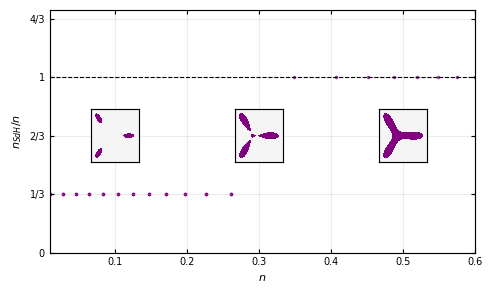

In [62]:
# kp_pocket_analysis.py
#
# Computes the Onsager/Luttinger pocket fraction f = n_pocket / n as a function
# of total filling n, for a general 2D k·p dispersion, and plots it onto a
# caller-supplied (fig, ax) with k-space pocket snapshots as insets.

import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ═══════════════════════════════════════════════════════════════════════════════
# Default parameters
# ═══════════════════════════════════════════════════════════════════════════════

# ── k-grid and μ scan ─────────────────────────────────────────────────────────
K_SCAN           = 8        # half-width of radial seed scans
NK_SCAN          = 10000    # points per seed-scan ray
SCAN_ANGLES      = [0.0, 2*math.pi/3, 4*math.pi/3]   # ray directions (covers C₃ pockets)
K_GRID_MAX       = 8        # half-width of 2D k-grid for n(μ)
NK_GRID          = 10000    # grid points per axis
N_MU             = 300      # number of μ values to scan
E_CUTOFF_SHIFTED = 200.0    # max energy above band minimum to scan

# ── Filling window ────────────────────────────────────────────────────────────
N_MIN = 0.01
N_MAX = 0.6

# ── Orbit tracing ─────────────────────────────────────────────────────────────
DS_ORBIT     = 0.012
CLOSURE_TOL  = 0.06
DEDUP_TOL    = 0.15
FRAC_THRESH  = 0.5
DEDUP_STRIDE = 5
G_S          = 1     # spin degeneracy

# ── k-space inset snapshots ───────────────────────────────────────────────────
N_TARGETS = [0.1, 0.3, 0.5]   # fillings at which to show inset snapshots
NK_KSPACE = 500


# ═══════════════════════════════════════════════════════════════════════════════
# k·p Hamiltonian
# ═══════════════════════════════════════════════════════════════════════════════

def _build_kp2(hparams):
    a2, a3, a4 = hparams
    return dict(
        H0    =  0.0,
        Hx    =  0.0,
        Hy    =  0.0,
        Hxx   =  a2,
        Hyy   =  a2,
        Hxy   =  0.0,
        Hxxx  = -a3,
        Hxxy  =  0.0,
        Hxyy  =  3*a3,
        Hyyy  =  0.0,
        Hxxxx =  a4,
        Hxxxy =  0.0,
        Hxxyy =  2*a4,
        Hxyyy =  0.0,
        Hyyyy =  a4,
    )


def eval_disp(kp, kx, ky):
    e  = kp['H0']
    e += kp['Hx']    * kx
    e += kp['Hy']    * ky
    e += kp['Hxx']   * kx**2
    e += kp['Hyy']   * ky**2
    e += kp['Hxy']   * kx * ky
    e += kp['Hxxx']  * kx**3
    e += kp['Hxxy']  * kx**2 * ky
    e += kp['Hxyy']  * kx    * ky**2
    e += kp['Hyyy']  * ky**3
    e += kp['Hxxxx'] * kx**4
    e += kp['Hxxxy'] * kx**3 * ky
    e += kp['Hxxyy'] * kx**2 * ky**2
    e += kp['Hxyyy'] * kx    * ky**3
    e += kp['Hyyyy'] * ky**4
    return e


def grad_disp(kp, kx, ky):
    gx  = kp['Hx']
    gx += 2*kp['Hxx']   * kx
    gx +=   kp['Hxy']   * ky
    gx += 3*kp['Hxxx']  * kx**2
    gx += 2*kp['Hxxy']  * kx * ky
    gx +=   kp['Hxyy']  * ky**2
    gx += 4*kp['Hxxxx'] * kx**3
    gx += 3*kp['Hxxxy'] * kx**2 * ky
    gx += 2*kp['Hxxyy'] * kx    * ky**2
    gx +=   kp['Hxyyy'] * ky**3

    gy  = kp['Hy']
    gy +=   kp['Hxy']   * kx
    gy += 2*kp['Hyy']   * ky
    gy +=   kp['Hxxy']  * kx**2
    gy += 2*kp['Hxyy']  * kx * ky
    gy += 3*kp['Hyyy']  * ky**2
    gy +=   kp['Hxxxy'] * kx**3
    gy += 2*kp['Hxxyy'] * kx**2 * ky
    gy += 3*kp['Hxyyy'] * kx    * ky**2
    gy += 4*kp['Hyyyy'] * ky**3

    return gx, gy


# ═══════════════════════════════════════════════════════════════════════════════
# Orbit tracing, deduplication, area
# ═══════════════════════════════════════════════════════════════════════════════

def trace_orbit(kp, kx0, ky0, ds=DS_ORBIT, closure_tol=CLOSURE_TOL, max_steps=500_000):
    def vel(kx, ky):
        gx, gy = grad_disp(kp, kx, ky)
        mag = math.hypot(gx, gy)
        if mag < 1e-14:
            return 0.0, 0.0
        return -gy / mag, gx / mag

    def rk4(kx, ky):
        vx1, vy1 = vel(kx,             ky)
        vx2, vy2 = vel(kx + ds/2*vx1,  ky + ds/2*vy1)
        vx3, vy3 = vel(kx + ds/2*vx2,  ky + ds/2*vy2)
        vx4, vy4 = vel(kx + ds*vx3,    ky + ds*vy3)
        return (kx + ds/6*(vx1 + 2*vx2 + 2*vx3 + vx4),
                ky + ds/6*(vy1 + 2*vy2 + 2*vy3 + vy4))

    kx, ky = kx0, ky0
    xs = [kx]; ys = [ky]
    max_dist = 0.0
    closed = False
    for _ in range(max_steps):
        kx, ky = rk4(kx, ky)
        xs.append(kx); ys.append(ky)
        d = math.hypot(kx - kx0, ky - ky0)
        max_dist = max(max_dist, d)
        if max_dist > 3*closure_tol and d < closure_tol:
            closed = True
            break
    xs.append(kx0); ys.append(ky0)
    return xs, ys, closed


def is_duplicate(xs_b, ys_b, xs_a, ys_a,
                 dist_tol=DEDUP_TOL, frac_thr=FRAC_THRESH, stride=DEDUP_STRIDE):
    ax = xs_a[::stride]; ay = ys_a[::stride]
    n_close = 0
    for i in range(0, len(xs_b), stride):
        xb, yb = xs_b[i], ys_b[i]
        for j in range(len(ax)):
            if math.hypot(xb - ax[j], yb - ay[j]) < dist_tol:
                n_close += 1
                break
    return n_close / math.ceil(len(xs_b) / stride) > frac_thr


def shoelace_area(xs, ys):
    xs, ys = np.asarray(xs), np.asarray(ys)
    return float(np.dot(xs[:-1], ys[1:]) - np.dot(xs[1:], ys[:-1])) / 2.0


def find_fermi_seeds(kp, mu, k_scan=K_SCAN, nk=NK_SCAN, angles=SCAN_ANGLES):
    dt = 2*k_scan / (nk - 1)
    seeds = []
    for theta in angles:
        ct, st = math.cos(theta), math.sin(theta)
        t_vec   = np.linspace(-k_scan, k_scan, nk)
        eps_vec = eval_disp(kp, t_vec * ct, t_vec * st)
        shifted = eps_vec - mu
        sign_changes = np.where(shifted[:-1] * shifted[1:] < 0)[0]
        for i in sign_changes:
            frac    = (mu - eps_vec[i]) / (eps_vec[i+1] - eps_vec[i])
            t_cross = t_vec[i] + frac * (t_vec[i+1] - t_vec[i])
            kx_s, ky_s = t_cross * ct, t_cross * st
            if not any(math.hypot(kx_s - s[0], ky_s - s[1]) < 3*dt for s in seeds):
                seeds.append((kx_s, ky_s))
    return seeds


# ═══════════════════════════════════════════════════════════════════════════════
# Main public function
# ═══════════════════════════════════════════════════════════════════════════════

def plot_pocket_filling(fig, ax, hparams,
                        n_mu=N_MU, n_targets=N_TARGETS,
                        scatter_color='steelblue',
                        verbose=False):
    """Plot Onsager/Luttinger pocket fraction f = n_pocket / n vs filling n
    onto a caller-supplied axis, with k-space pocket snapshots as insets.

    Parameters
    ----------
    fig : matplotlib.figure.Figure
        Parent figure.
    ax : matplotlib.axes.Axes
        Axis to draw the f-vs-n scatter onto.
    hparams : tuple
        (a2, a3, a4) k·p coefficients.
    n_mu : int, optional
        Number of μ values to scan. Reduce for faster tests.
    n_targets : list of float, optional
        Fillings at which to show inset k-space snapshots.
    scatter_color : str, optional
        Color for the f-vs-n scatter.
    verbose : bool, optional
        If True, print progress and diagnostics.

    Returns
    -------
    dict with keys
        'n'         : array of filling values
        'n_pocket'  : array of per-pocket Luttinger areas
        'f'         : ratio n_pocket / n
        'insets'    : list of (n_target, axis) for the inset axes
    """
    kp = _build_kp2(hparams)

    # ── k-grid and n(μ) lookup ────────────────────────────────────────────────
    if verbose:
        print("Building k-grid …")
    k_1d = np.linspace(-K_GRID_MAX, K_GRID_MAX, NK_GRID)
    dk   = float(k_1d[1] - k_1d[0])
    KX, KY = np.meshgrid(k_1d, k_1d)
    E_grid = eval_disp(kp, KX, KY)

    E_min_raw = float(E_grid.min())
    E_max_raw = float(E_grid.max())
    if verbose:
        print(f"  ε_min = {E_min_raw:.5g}, ε_max = {E_max_raw:.5g}")

    E_sorted = np.sort(E_grid.ravel())

    def n_of_mu(mu):
        return G_S * int(np.searchsorted(E_sorted, mu, side='right')) * dk**2 / (2*math.pi)**2

    def n_to_mu(n):
        idx = max(0, min(len(E_sorted)-1,
                         round(n * (2*math.pi)**2 / (G_S * dk**2)) - 1))
        return float(E_sorted[idx])

    mu_lo_n = n_to_mu(N_MIN) if N_MIN > 0 else E_min_raw + 0.05
    mu_hi_n = n_to_mu(N_MAX) if math.isfinite(N_MAX) else min(E_min_raw + E_CUTOFF_SHIFTED, E_max_raw - 0.05)
    mu_min  = max(E_min_raw + 0.05, mu_lo_n)
    mu_max  = min(min(E_min_raw + E_CUTOFF_SHIFTED, E_max_raw - 0.05), mu_hi_n)
    mu_vals = np.linspace(mu_min, mu_max, n_mu)

    if verbose:
        print(f"μ scan: [{mu_min - E_min_raw:.3g}, {mu_max - E_min_raw:.3g}] above band min")
        print(f"n scan: [{n_of_mu(mu_min):.3g}, {n_of_mu(mu_max):.3g}]")
        print(f"Scanning {n_mu} chemical potentials …")

    # ── Main loop: pocket tracing per μ ───────────────────────────────────────
    n_vals_all   = []
    n_pocket_all = []
    is_electron  = []

    for i_mu, mu in enumerate(mu_vals):
        seeds = find_fermi_seeds(kp, mu)
        if not seeds:
            continue
        n_total = n_of_mu(mu)
        if n_total <= 0:
            continue

        acc_xs = []; acc_ys = []
        for kx0, ky0 in seeds:
            xs, ys, closed = trace_orbit(kp, kx0, ky0)
            if not closed:
                continue
            if any(is_duplicate(xs, ys, ax_, ay_) for ax_, ay_ in zip(acc_xs, acc_ys)):
                continue
            acc_xs.append(xs); acc_ys.append(ys)
            A_signed = shoelace_area(xs, ys)
            n_vals_all.append(n_total)
            n_pocket_all.append(abs(A_signed) * G_S / (2*math.pi)**2)
            is_electron.append(A_signed > 0)

        if verbose and ((i_mu + 1) % 25 == 0 or i_mu == n_mu - 1):
            print(f"  [{i_mu+1:3d}/{n_mu}]  n={n_total:.3g}  pockets={len(acc_xs)}")

    n_vals_all   = np.array(n_vals_all)
    n_pocket_all = np.array(n_pocket_all)
    ratio_all    = n_pocket_all / n_vals_all if len(n_vals_all) else np.array([])

    # ── Main scatter ──────────────────────────────────────────────────────────
    x_lo = N_MIN if N_MIN > 0 else (n_vals_all.min() if len(n_vals_all) else 0.0)
    x_hi = N_MAX if math.isfinite(N_MAX) else (n_vals_all.max() if len(n_vals_all) else 1.0)
    y_hi = max(4/3, ratio_all.max()) if len(ratio_all) else 4/3

    ax.set_xlabel('$n$')
    ax.set_ylabel('$n_{SdH}/n$')
    ax.set_xlim(x_lo, x_hi)
    ax.set_ylim(0.0, y_hi + 0.05)
    ax.set_yticks([0.0, 1/3, 2/3, 1.0, 4/3])
    ax.set_yticklabels(["0", "1/3", "2/3", "1", "4/3"])
    ax.grid(True, alpha=0.25)
    ax.scatter(n_vals_all, ratio_all,
               color=scatter_color, s=2.5**2, linewidths=0, alpha=0.8)
    ax.axhline(y=1.0, color='black', linestyle='--', linewidth=0.8)

    # ── Inset k-space snapshots ───────────────────────────────────────────────
    ks_stride = max(1, NK_GRID // NK_KSPACE)
    kx_ax = k_1d[::ks_stride]
    ky_ax = k_1d[::ks_stride]
    nk_ks = len(kx_ax)
    E_sub = E_grid[::ks_stride, ::ks_stride]

    cmap_fs = LinearSegmentedColormap.from_list('fs', ['whitesmoke', scatter_color])

    inset_axes_list = []
    # Place each inset centered at (n_tgt, 2/3) in data coords, sized via a
    # non-degenerate bbox in axes-fraction coords.
    inset_w_ax  = 0.16   # fraction of axis width
    inset_h_ax  = 0.22   # fraction of axis height
    inset_y_ax  = (2/3) / (y_hi + 0.05)   # y position in axes fraction
    x_span = x_hi - x_lo

    for n_tgt in n_targets:
        i_target = max(0, min(len(E_sorted)-1,
                              round(n_tgt * (2*math.pi)**2 / (G_S * dk**2)) - 1))
        mu_target = float(E_sorted[i_target])
        filled_mask = E_sub < mu_target
        if not filled_mask.any():
            continue
        z_snap = filled_mask.astype(float)

        # Tight bbox around the filled region
        filled_cols = np.where(filled_mask.any(axis=0))[0]
        filled_rows = np.where(filled_mask.any(axis=1))[0]
        pad = math.ceil(0.05 * nk_ks)
        col_lo  = max(0,        int(filled_cols.min()) - pad)
        col_hi  = min(nk_ks-1,  int(filled_cols.max()) + pad)
        row_lo  = max(0,        int(filled_rows.min()) - pad)
        row_hi  = min(nk_ks-1,  int(filled_rows.max()) + pad)

        # Inset centered horizontally at n_tgt
        x_frac = (n_tgt - x_lo) / x_span
        bbox = (x_frac - inset_w_ax/2, inset_y_ax - inset_h_ax/2,
                inset_w_ax, inset_h_ax)
        ax_in = inset_axes(
            ax,
            width="100%", height="100%",
            loc='center',
            bbox_to_anchor=bbox,
            bbox_transform=ax.transAxes,
            borderpad=0,
        )
        ax_in.pcolormesh(kx_ax, ky_ax, z_snap, cmap=cmap_fs,
                         vmin=0.0, vmax=1.0, shading='auto', rasterized=True, lw=0)
        ax_in.set_aspect('equal')
        ax_in.set_xlim(kx_ax[col_lo], kx_ax[col_hi])
        ax_in.set_ylim(ky_ax[row_lo], ky_ax[row_hi])
        ax_in.set_xticks([]); ax_in.set_yticks([])
        #for spine in ax_in.spines.values():
        #    spine.set_visible(False)
        ax_in.set_facecolor('whitesmoke')
        inset_axes_list.append((n_tgt, ax_in))

    return {
        'n':        n_vals_all,
        'n_pocket': n_pocket_all,
        'f':        ratio_all,
        'insets':   inset_axes_list,
    }


fig, ax = plt.subplots(figsize=(5, 3))
plot_pocket_filling(fig, ax, hparams=(5.5, 6, 1), n_mu=20, verbose=True, scatter_color="purple")
plt.tight_layout()
plt.show()

# Full figure

Building k-grid …
  ε_min = 2.048e-05, ε_max = 17920
μ scan: [0.516, 85.3] above band min
n scan: [0.01, 0.6]
Scanning 500 chemical potentials …
  [ 25/500]  n=0.0756  pockets=1
  [ 50/500]  n=0.129  pockets=1
  [ 75/500]  n=0.173  pockets=1
  [100/500]  n=0.213  pockets=1
  [125/500]  n=0.248  pockets=1
  [150/500]  n=0.28  pockets=1
  [175/500]  n=0.311  pockets=1
  [200/500]  n=0.339  pockets=1
  [225/500]  n=0.366  pockets=1
  [250/500]  n=0.391  pockets=1
  [275/500]  n=0.416  pockets=1
  [300/500]  n=0.439  pockets=1
  [325/500]  n=0.461  pockets=1
  [350/500]  n=0.483  pockets=1
  [375/500]  n=0.504  pockets=1
  [400/500]  n=0.524  pockets=1
  [425/500]  n=0.544  pockets=1
  [450/500]  n=0.563  pockets=1
  [475/500]  n=0.582  pockets=1
  [500/500]  n=0.6  pockets=1
Building k-grid …
  ε_min = -41.318, ε_max = 23232
μ scan: [2.01, 67.6] above band min
n scan: [0.01, 0.6]
Scanning 500 chemical potentials …
  [ 25/500]  n=0.026  pockets=3
  [ 50/500]  n=0.0432  pockets=3
  [ 75/500

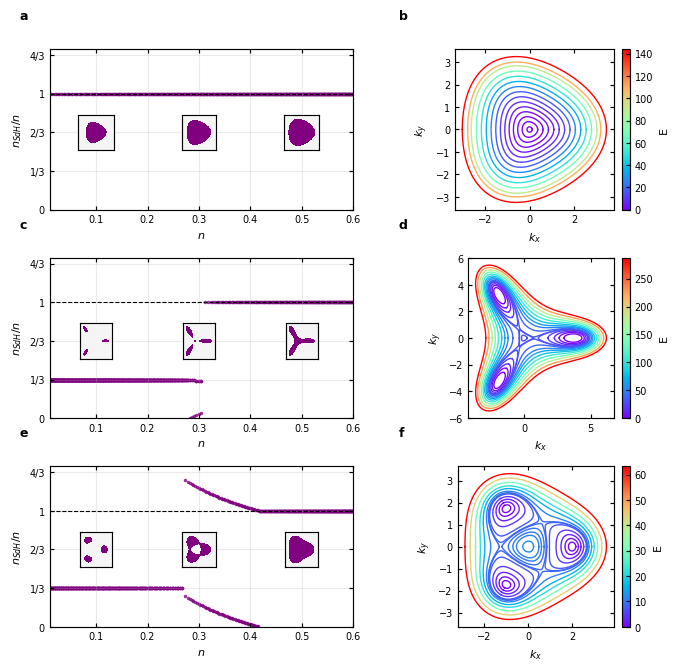

In [63]:
fig = plt.figure(figsize=(7.5, 7.5))
gs = GridSpec(3, 2, figure=fig,   
                       width_ratios=[1.5, 1],
                       height_ratios=[1, 1, 1],
                       hspace=0.3, wspace=0.3)

hparams_vec = [(4,1,1), (5.5, 6, 1), (-5,1,1)]
################ Panels left col ##################

# ═══════════════════════════════════════════════════════════════════════════════
# Default parameters for pockets
# ═══════════════════════════════════════════════════════════════════════════════

# ── k-grid and μ scan ─────────────────────────────────────────────────────────
K_SCAN           = 8        # half-width of radial seed scans
NK_SCAN          = 5000    # points per seed-scan ray
SCAN_ANGLES      = [0.0, 2*math.pi/3, 4*math.pi/3]   # ray directions (covers C₃ pockets)
K_GRID_MAX       = 8        # half-width of 2D k-grid for n(μ)
NK_GRID          = 5000    # grid points per axis
N_MU             = 300      # number of μ values to scan
E_CUTOFF_SHIFTED = 200.0    # max energy above band minimum to scan

# ── Filling window ────────────────────────────────────────────────────────────
N_MIN = 0.01
N_MAX = 0.6

# ── Orbit tracing ─────────────────────────────────────────────────────────────
DS_ORBIT     = 0.012
CLOSURE_TOL  = 0.06
DEDUP_TOL    = 0.15
FRAC_THRESH  = 0.5
DEDUP_STRIDE = 5
G_S          = 1     # spin degeneracy

# ── k-space inset snapshots ───────────────────────────────────────────────────
N_TARGETS = [0.1, 0.3, 0.5]   # fillings at which to show inset snapshots
NK_KSPACE = 500

label_vec = ["a", "c", "e"]
for ax_ind, label in enumerate(label_vec):
    ax = fig.add_subplot(gs[ax_ind, 0])
    fig.canvas.draw()  
    pos = ax.get_position()
    label_spacer = 0.04
    fig.text(pos.x0 - label_spacer, pos.y1 + label_spacer, label, fontweight='bold')
    plot_pocket_filling(fig, ax, hparams=hparams_vec[ax_ind], n_mu=500, verbose=True, scatter_color="purple")
    
################ Panels right col ##################
label_vec = ["b", "d", "f"]


# ═══════════════════════════════════════════════════════════════════════════════
# Default parameters for contours
# ═══════════════════════════════════════════════════════════════════════════════

# ── Anchor grid ───────────────────────────────────────────────────────────────
K_START  = 3.0     # innermost anchor radius (negative samples the other side)
K_END    = -3.0    # outermost anchor radius
N_ORBITS = 51     # number of radial distances; up to 3×N_ORBITS anchors total
K_MIN    = 0.1     # anchors with |r| < K_MIN are skipped (avoids gradient≈0 near Γ)

# ── Orbit tracing ─────────────────────────────────────────────────────────────
DS          = 0.005   # arc-length step size
CLOSURE_TOL = 0.01    # orbit closed when dist-to-start < this

# ── Deduplication ─────────────────────────────────────────────────────────────
DEDUP_TOL    = 0.15   # two orbits are duplicates if points are within this distance
FRAC_THRESH  = 0.75   # fraction of subsampled points that must overlap to deduplicate
DEDUP_STRIDE = 10     # stride for subsampling during deduplication




for ax_ind, label in enumerate(label_vec):
    ax = fig.add_subplot(gs[ax_ind, 1])
    #fig.canvas.draw()  
    pos = ax.get_position()
    label_spacer = 0.04
    fig.text(pos.x0 - label_spacer, pos.y1 + label_spacer, label, fontweight='bold')
    plot_contours(fig, ax, hparams=hparams_vec[ax_ind], cmap='rainbow', verbose=False)

fig.savefig("si-fig-onsager-model.pdf", dpi=600,
            pad_inches=0.02, transparent=False)